In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Define the ZIP file path and the csv filename inside the ZIP
zip_path = "../dataset/diabetes_dataset_1999_2008.zip"  
csv_filename = "diabetic_data.csv"  

# Open the ZIP file and read the csv file
with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open(csv_filename) as f:
        # Load the csv file content 
        diabetic_data = pd.read_csv(f)

In [3]:
# check the data randomly
diabetic_data.sample(n=5)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
73298,216295068,43639209,Caucasian,Male,[60-70),?,3,1,1,4,...,No,Down,No,No,No,No,No,Ch,Yes,>30
16565,62021406,4104585,Caucasian,Female,[50-60),?,3,1,1,1,...,No,No,No,No,No,No,No,No,Yes,<30
85408,270339564,103679721,Caucasian,Female,[40-50),?,1,1,7,4,...,No,No,No,No,No,No,No,Ch,Yes,NO
79239,242891526,36642519,Caucasian,Female,[80-90),?,3,3,7,8,...,No,Up,No,No,No,No,No,Ch,Yes,>30
56548,162322242,103691484,Caucasian,Male,[60-70),?,1,1,7,2,...,No,Steady,No,No,No,No,No,Ch,Yes,>30


## Data Cleaning and EDA

In [4]:
diabetic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
diabetic_data.isnull().sum()

encounter_id                    0
patient_nbr                     0
race                            0
gender                          0
age                             0
weight                          0
admission_type_id               0
discharge_disposition_id        0
admission_source_id             0
time_in_hospital                0
payer_code                      0
medical_specialty               0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
number_outpatient               0
number_emergency                0
number_inpatient                0
diag_1                          0
diag_2                          0
diag_3                          0
number_diagnoses                0
max_glu_serum               96420
A1Cresult                   84748
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [6]:
(diabetic_data == '?').sum().sum()

192849

In [7]:
# find unknown values and replace them with nan
diabetic_data = diabetic_data.replace('?', np.nan)
(diabetic_data == '?').sum().sum()

0

In [8]:
diabetic_data['age'].value_counts()

age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

In [9]:
age_map = {
    '[0-10)'   : 0,
    '[10-20)'  : 1,
    '[20-30)'  : 2,
    '[30-40)'  : 3,
    '[40-50)'  : 4,
    '[50-60)'  : 5,
    '[60-70)'  : 6,
    '[70-80)'  : 7,
    '[80-90)'  : 8,
    '[90-100)' : 9
}
diabetic_data['age_encoded'] = diabetic_data['age'].map(age_map)
diabetic_data[['age', 'age_encoded']]

,age,age_encoded
0,[0-10),0
1,[10-20),1
2,[20-30),2
3,[30-40),3
4,[40-50),4
...,...,...
101761,[70-80),7
101762,[80-90),8
101763,[70-80),7
101764,[80-90),8


In [10]:
diabetic_data.shape

(101766, 51)

In [11]:
print(diabetic_data['gender'].value_counts())
print(diabetic_data['race'].value_counts())

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


In [12]:
# Remove rows with unknown gender
diabetic_data = diabetic_data[diabetic_data['gender'] != 'Unknown/Invalid']

# Encode gender: Female = 0, Male = 1
gender_map = {'Female': 0, 'Male': 1}
diabetic_data['gender_encoded'] = diabetic_data['gender'].map(gender_map)


# One-hot encode race
race_dummies = pd.get_dummies(diabetic_data['race'], prefix='race', dtype=int)
diabetic_data = pd.concat([diabetic_data, race_dummies], axis=1)

In [13]:
print(diabetic_data.shape)
print(diabetic_data.columns)

(101763, 57)
Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted',
       'age_encoded', 'gender_encoded', 'race_AfricanAmerican', 'race_Asian',
 

In [14]:
diabetic_data['diag_2'].unique()

array([nan, '250.01', '250', '250.43', '157', '411', '492', '427', '198',
       '403', '288', '998', '507', '174', '425', '456', '401', '715',
       '496', '428', '585', '250.02', '410', '999', '996', '135', '244',
       '41', '571', '276', '997', '599', '424', '491', '553', '707',
       '286', '440', '493', '242', '70', 'V45', '250.03', '357', '511',
       '196', '396', '197', '414', '250.52', '577', '535', '413', '285',
       '53', '780', '518', '150', '566', '250.6', '867', '486', 'V15',
       '8', '788', '340', '574', '581', '228', '530', '250.82', '786',
       '294', '567', '785', '512', '305', '729', '250.51', '280', '648',
       '560', '618', '444', '38', 'V10', '578', '277', '781', '250.42',
       '278', '426', '584', '462', '402', '153', '272', '733', '34',
       '881', '203', '250.41', '250.13', '293', '245', '250.12', '558',
       '787', '342', '573', '626', '303', '250.53', '458', '710', '415',
       'V42', '284', '569', '759', '682', '112', '292', '435', '290'

In [15]:
# Count how many diag_2 values start with a non-digit (e.g., 'V', 'E')
non_numeric_diag = diabetic_data['diag_1'].astype(str)
non_numeric_diag = non_numeric_diag[non_numeric_diag.str.match(r'^[A-Za-z]')]

# Get value counts
non_numeric_diag.value_counts().sum()

1666

In [16]:
# Frequency counts for categorical columns
print(diabetic_data['readmitted'].value_counts())

readmitted
NO     54861
>30    35545
<30    11357
Name: count, dtype: int64


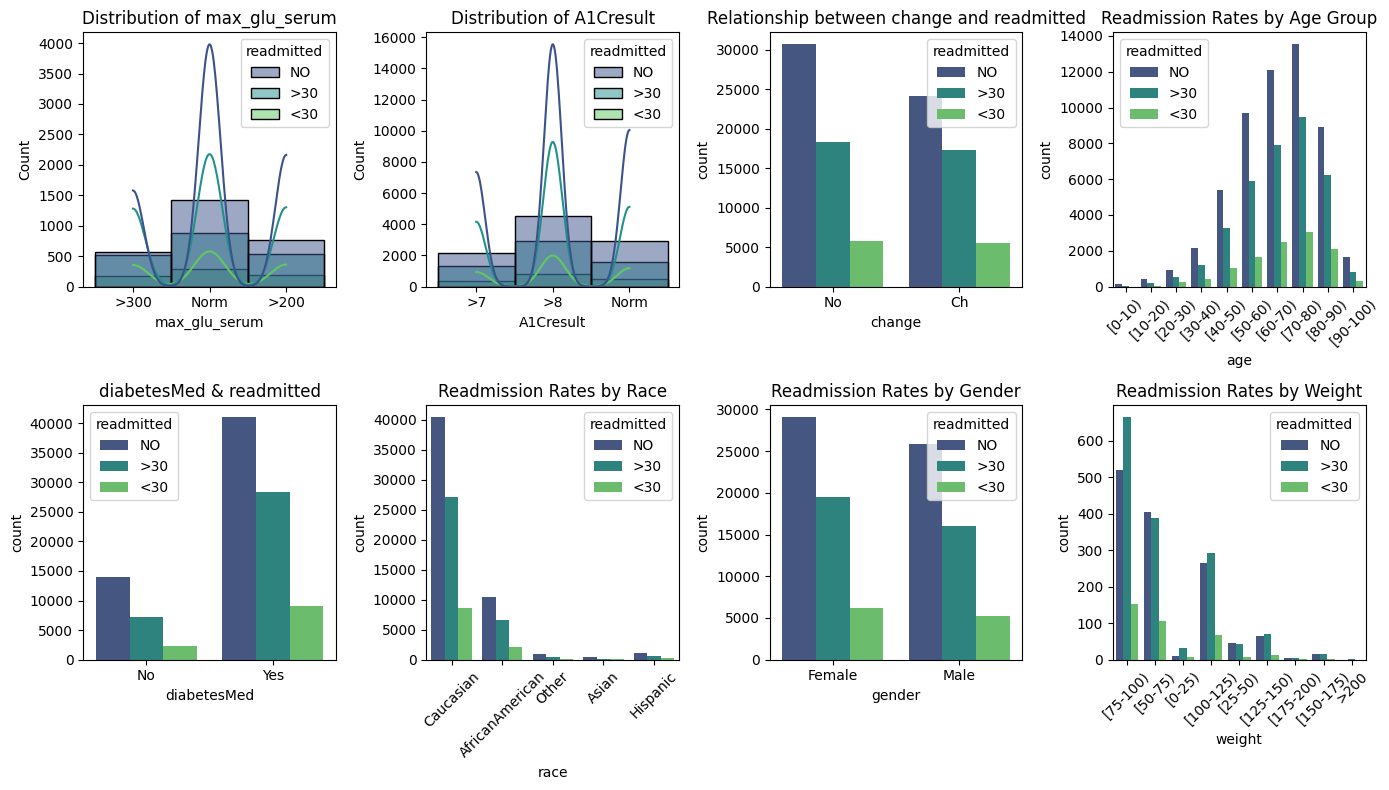

In [17]:
# Create a 2x3 grid layout
fig, axes = plt.subplots(2, 4, figsize=(14, 8))

# Distribution of max_glu_serum
sns.histplot(x='max_glu_serum', hue='readmitted', 
             palette='viridis', data=diabetic_data, ax=axes[0, 0], kde=True)
axes[0, 0].set_title("Distribution of max_glu_serum", fontsize=12)

# Distribution of A1Cresult
sns.histplot(x='A1Cresult', hue='readmitted', 
             palette='viridis', data=diabetic_data, ax=axes[0, 1], kde=True)
axes[0, 1].set_title("Distribution of A1Cresult", fontsize=12)

# Relationship between change and readmitted
sns.countplot(x='change', hue='readmitted', 
              palette='viridis', data=diabetic_data, ax=axes[0, 2])
axes[0, 2].set_title("Relationship between change and readmitted", fontsize=12)

# Age Analysis
sns.countplot(x='age', hue='readmitted', 
              palette='viridis', data=diabetic_data, ax=axes[0, 3])
axes[0, 3].set_title('Readmission Rates by Age Group', fontsize=12)
axes[0, 3].tick_params(axis='x', rotation=45)  

# Relationship between diabetesMed and readmitted
sns.countplot(x='diabetesMed', hue='readmitted', 
              palette='viridis', data=diabetic_data, ax=axes[1, 0])
axes[1, 0].set_title("diabetesMed & readmitted", fontsize=12)

# Race and Gender Analysis
sns.countplot(x='race', hue='readmitted', 
              palette='viridis', data=diabetic_data, ax=axes[1, 1])
axes[1, 1].set_title('Readmission Rates by Race', fontsize=12)
axes[1, 1].tick_params(axis='x', rotation=45)  # Rotate race labels

sns.countplot(x='gender', hue='readmitted', 
              palette='viridis', data=diabetic_data, ax=axes[1, 2])
axes[1, 2].set_title('Readmission Rates by Gender', fontsize=12)

# Weight Analysis
sns.countplot(x='weight', hue='readmitted', 
              palette='viridis', data=diabetic_data, ax=axes[1, 3])
axes[1, 3].set_title('Readmission Rates by Weight', fontsize=12)
axes[1, 3].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

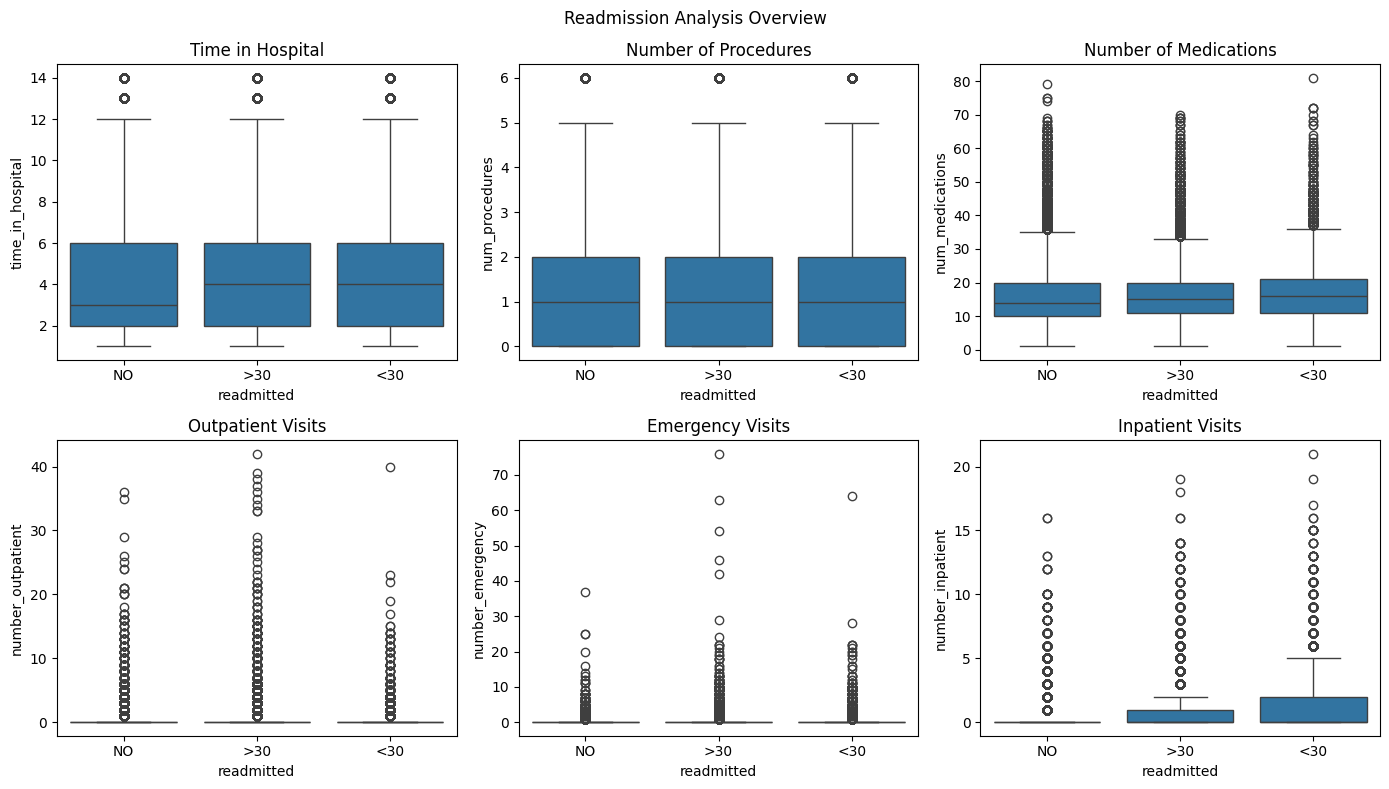

In [18]:
# Create a 3x3 grid layout
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Readmission Analysis Overview')

# Time in Hospital
sns.boxplot(x='readmitted', y='time_in_hospital', data=diabetic_data, ax=axes[0, 0])
axes[0, 0].set_title('Time in Hospital')

# Number of Procedures
sns.boxplot(x='readmitted', y='num_procedures', data=diabetic_data, ax=axes[0, 1])
axes[0, 1].set_title('Number of Procedures')

# Number of Medications
sns.boxplot(x='readmitted', y='num_medications', data=diabetic_data, ax=axes[0, 2])
axes[0, 2].set_title('Number of Medications')

# Outpatient Visits
sns.boxplot(x='readmitted', y='number_outpatient', data=diabetic_data, ax=axes[1, 0])
axes[1, 0].set_title('Outpatient Visits')

# Emergency Visits
sns.boxplot(x='readmitted', y='number_emergency', data=diabetic_data, ax=axes[1, 1])
axes[1, 1].set_title('Emergency Visits')

# Inpatient Visits
sns.boxplot(x='readmitted', y='number_inpatient', data=diabetic_data, ax=axes[1, 2])
axes[1, 2].set_title('Inpatient Visits')


# Improve layout
plt.tight_layout()
plt.show()


In [19]:
# take the first 3 characters to group diagnoses
diabetic_data['diag_1'] = diabetic_data['diag_1'].astype(str).str[:3]
diabetic_data['diag_2'] = diabetic_data['diag_2'].astype(str).str[:3]
diabetic_data['diag_3'] = diabetic_data['diag_3'].astype(str).str[:3]

In [20]:
# Convert numeric-looking strings to numeric
# diabetic_data['diag_1_num'] = pd.to_numeric(diabetic_data['diag_1'], errors='coerce')
# diabetic_data['diag_2_num'] = pd.to_numeric(diabetic_data['diag_2'], errors='coerce')
# diabetic_data['diag_3_num'] = pd.to_numeric(diabetic_data['diag_3'], errors='coerce')

In [21]:
# create a mapping function
def map_icd9_category(code):
    try:
        code = float(code)
        if 1 <= code <= 139:
            return 'Infectious'
        elif 140 <= code <= 239:
            return 'Neoplasms'
        elif 240 <= code <= 279:
            return 'Endocrine'
        elif 280 <= code <= 289:
            return 'Blood'
        elif 290 <= code <= 319:
            return 'Mental'
        elif 390 <= code <= 459:
            return 'Circulatory'
        elif 460 <= code <= 519:
            return 'Respiratory'
        elif 520 <= code <= 579:
            return 'Digestive'
        elif 580 <= code <= 629:
            return 'Genitourinary'
        elif 630 <= code <= 679:
            return 'Pregnancy'
        elif 680 <= code <= 709:
            return 'Skin'
        elif 710 <= code <= 739:
            return 'Musculoskeletal'
        elif 740 <= code <= 759:
            return 'Congenital'
        elif 780 <= code <= 799:
            return 'Symptoms'
        elif 800 <= code <= 999:
            return 'Injury'
    except:
        if str(code).startswith('V'):
            return 'Supplementary'
        elif str(code).startswith('E'):
            return 'External Causes'
    return 'Unknown'

# Apply the function
diabetic_data['diag_1_category'] = diabetic_data['diag_1'].apply(map_icd9_category)
diabetic_data['diag_2_category'] = diabetic_data['diag_2'].apply(map_icd9_category)
diabetic_data['diag_3_category'] = diabetic_data['diag_3'].apply(map_icd9_category)

In [22]:
diabetic_data.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,age_encoded,gender_encoded,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other,diag_1_category,diag_2_category,diag_3_category
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,0,0,0,0,1,0,0,Endocrine,Unknown,Unknown
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,1,0,0,0,1,0,0,Endocrine,Endocrine,Endocrine
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,2,0,1,0,0,0,0,Pregnancy,Endocrine,Supplementary
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,3,1,0,0,1,0,0,Infectious,Endocrine,Circulatory
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,4,1,0,0,1,0,0,Neoplasms,Neoplasms,Endocrine


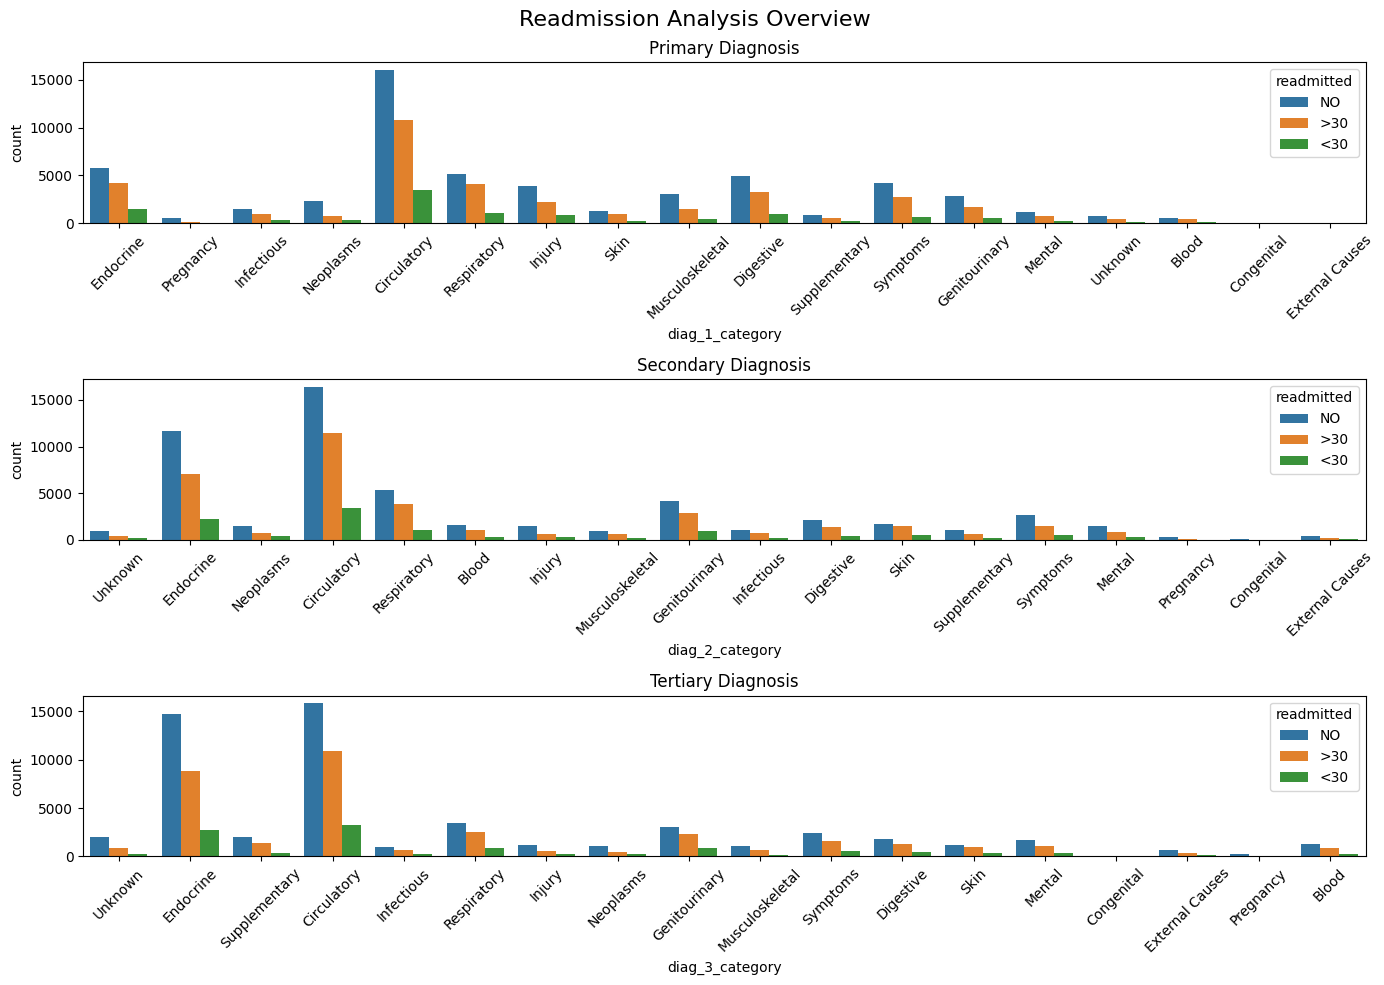

In [23]:
# Create a 3x1 grid layout
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Readmission Analysis Overview', fontsize=16)

# Primary Diagnosis
sns.countplot(x='diag_1_category', hue='readmitted', data=diabetic_data, ax=axes[0])
axes[0].set_title('Primary Diagnosis')
axes[0].tick_params(axis='x', rotation=45)

# Secondary Diagnosis
sns.countplot(x='diag_2_category', hue='readmitted', data=diabetic_data, ax=axes[1])
axes[1].set_title('Secondary Diagnosis')
axes[1].tick_params(axis='x', rotation=45)

# Tertiary Diagnosis
sns.countplot(x='diag_3_category', hue='readmitted', data=diabetic_data, ax=axes[2])
axes[2].set_title('Tertiary Diagnosis')
axes[2].tick_params(axis='x', rotation=45)

# Improve layout
plt.tight_layout()
plt.show()


In [24]:
diabetic_data = diabetic_data.drop(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
                                    'payer_code', 'medical_specialty','diag_1',
                                    'diag_2', 'diag_3','examide', 'citoglipton'], axis=1)

In [25]:
diabetic_data.shape

(101763, 48)

In [26]:
print(diabetic_data['max_glu_serum'].value_counts())
print(diabetic_data['max_glu_serum'].value_counts().sum())
print(diabetic_data['A1Cresult'].value_counts())
print(diabetic_data['A1Cresult'].value_counts().sum())

max_glu_serum
Norm    2597
>200    1485
>300    1264
Name: count, dtype: int64
5346
A1Cresult
>8      8216
Norm    4990
>7      3812
Name: count, dtype: int64
17018


* Note: Seeing this result, we can conclude on majority of the patient glucose serum test was not performed or test was not taken.

In [27]:
print(diabetic_data['max_glu_serum'].isnull().sum())
print(diabetic_data['A1Cresult'].isnull().sum())

96417
84745


In [28]:
print(diabetic_data['max_glu_serum'].unique())

[nan '>300' 'Norm' '>200']


In [29]:
# Encode max_glu_serum
glu_serum_map = {'Norm': 1, '>200': 2, '>300': 3}
diabetic_data['glu_serum_encod'] = diabetic_data['max_glu_serum'].map(glu_serum_map)

# Encode A1Cresult
A1Cresult_map = {'Norm': 1, '>7': 2, '>8': 3}
diabetic_data['A1Cresult_encod'] = diabetic_data['A1Cresult'].map(A1Cresult_map)

print(diabetic_data['glu_serum_encod'].unique())
print(diabetic_data['A1Cresult_encod'].unique())

[nan  3.  1.  2.]
[nan  2.  3.  1.]


In [30]:
diabetic_data['glu_serum_encod'] = diabetic_data['glu_serum_encod'].replace(['None', None], 0)
diabetic_data['glu_serum_encod'] = diabetic_data['glu_serum_encod'].fillna(0)

diabetic_data['A1Cresult_encod'] = diabetic_data['A1Cresult_encod'].replace(['None', None], 0)
diabetic_data['A1Cresult_encod'] = diabetic_data['A1Cresult_encod'].fillna(0)

print(diabetic_data['glu_serum_encod'].unique())
print(diabetic_data['A1Cresult_encod'].unique())

[0. 3. 1. 2.]
[0. 2. 3. 1.]


In [31]:
diabetic_data['glu_serum_encod'] = diabetic_data['glu_serum_encod'].astype(int)
diabetic_data['A1Cresult_encod'] = diabetic_data['A1Cresult_encod'].astype(int)

In [32]:
print(diabetic_data['A1Cresult_encod'].isna().sum())

0


In [33]:
# Drop the origional coulmns-'max_glu_serum', 'A1Cresult'
diabetic_data = diabetic_data.drop(['max_glu_serum', 'A1Cresult'], axis=1)

In [34]:
pd.set_option('future.no_silent_downcasting', True)

med_columns = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
               'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 
               'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol','insulin','glyburide-metformin']

# Define mapping
med_encoding = {'No': 0, 'Steady': 1, 'Up': 2, 'Down': 3}

# Apply mapping
diabetic_data[med_columns] = diabetic_data[med_columns].replace(med_encoding)
diabetic_data[med_columns] = diabetic_data[med_columns].infer_objects(copy=False)

In [35]:
pd.set_option('future.no_silent_downcasting', True)

med_columns2 = ['acetohexamide', 'tolbutamide', 'troglitazone', 'glipizide-metformin', 'glimepiride-pioglitazone',
               'metformin-rosiglitazone', 'metformin-pioglitazone']

# Define mapping
med_encoding2 = {'No': 0, 'Steady': 1}
tolaz_map = {'No': 0, 'Steady': 1, 'Up': 2}

# Apply mapping
diabetic_data[med_columns2] = diabetic_data[med_columns2].replace(med_encoding2)
diabetic_data[med_columns2] = diabetic_data[med_columns2].infer_objects(copy=False)

diabetic_data['tolazamide'] = diabetic_data['tolazamide'].replace(tolaz_map)
diabetic_data['tolazamide'] = diabetic_data['tolazamide'].infer_objects(copy=False)

In [36]:
# Define mapping
change_map = {'No': 0, 'Ch': 1}
diab_med_map = {'No': 0, 'Yes': 1}
readmit_map = {'NO': 0, '<30': 1, '>30': 1}

# Apply mapping
diabetic_data['change'] = diabetic_data['change'].map(change_map)
diabetic_data['diabetesMed'] = diabetic_data['diabetesMed'].map(diab_med_map)
diabetic_data['readmitted'] = diabetic_data['readmitted'].map(readmit_map)

In [37]:
diabetic_data['diag_1_category'].unique()

array(['Endocrine', 'Pregnancy', 'Infectious', 'Neoplasms', 'Circulatory',
       'Respiratory', 'Injury', 'Skin', 'Musculoskeletal', 'Digestive',
       'Supplementary', 'Symptoms', 'Genitourinary', 'Mental', 'Unknown',
       'Blood', 'Congenital', 'External Causes'], dtype=object)

In [38]:
# Create category-to-number dictionary
diag_categories = ['Endocrine', 'Pregnancy', 'Infectious', 'Neoplasms', 'Circulatory', 
                   'Respiratory', 'Injury', 'Skin', 'Musculoskeletal', 'Digestive',
                   'Supplementary', 'Symptoms', 'Genitourinary', 'Mental', 'Unknown',
                   'Blood', 'Congenital', 'External Causes']

diag_map = {category: idx for idx, category in enumerate(diag_categories)}
diag_map

{'Endocrine': 0,
 'Pregnancy': 1,
 'Infectious': 2,
 'Neoplasms': 3,
 'Circulatory': 4,
 'Respiratory': 5,
 'Injury': 6,
 'Skin': 7,
 'Musculoskeletal': 8,
 'Digestive': 9,
 'Supplementary': 10,
 'Symptoms': 11,
 'Genitourinary': 12,
 'Mental': 13,
 'Unknown': 14,
 'Blood': 15,
 'Congenital': 16,
 'External Causes': 17}

In [39]:
# Apply the mapping
diabetic_data['diag_1_cat_encod'] = diabetic_data['diag_1_category'].map(diag_map)
diabetic_data['diag_2_cat_encod'] = diabetic_data['diag_2_category'].map(diag_map)
diabetic_data['diag_2_cat_encod'] = diabetic_data['diag_3_category'].map(diag_map)

# Drop the origionalcolumns
diabetic_data = diabetic_data.drop(columns=['diag_1_category', 'diag_2_category', 'diag_3_category'])

In [40]:
diabetic_data['weight'].isnull().sum()

98566

In [41]:
print(diabetic_data['weight'].unique())
print(diabetic_data['weight'].value_counts())

[nan '[75-100)' '[50-75)' '[0-25)' '[100-125)' '[25-50)' '[125-150)'
 '[175-200)' '[150-175)' '>200']
weight
[75-100)     1336
[50-75)       897
[100-125)     625
[125-150)     145
[25-50)        97
[0-25)         48
[150-175)      35
[175-200)      11
>200            3
Name: count, dtype: int64


In [42]:
# Handling missing value
# mode_weight = diabetic_data['weight'].mode()[0]
diabetic_data['weight'] = diabetic_data['weight'].ffill().bfill()

In [43]:
print(diabetic_data['weight'].value_counts())

weight
[75-100)     44065
[50-75)      28249
[100-125)    18437
[125-150)     4899
[25-50)       2915
[0-25)        1828
[150-175)      937
[175-200)      366
>200            67
Name: count, dtype: int64


In [44]:
diabetic_data['weight'].unique()

array(['[75-100)', '[50-75)', '[0-25)', '[100-125)', '[25-50)',
       '[125-150)', '[175-200)', '[150-175)', '>200'], dtype=object)

In [45]:
# Create an orderd list and mapping dictionaries
weight_categories = ['[0-25)', '[25-50)', '[50-75)', '[75-100)', '[100-125)', 
                     '[125-150)', '[150-175)', '[175-200)', '>200']

weight_encoding = {cat: idx for idx, cat in enumerate(weight_categories)}

# encode the weight value
diabetic_data['weight_encod'] = diabetic_data['weight'].map(weight_encoding)

# Drop original column
diabetic_data = diabetic_data.drop(columns=['weight'])

# Check the cleaned df
diabetic_data.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,race_AfricanAmerican,race_Asian,race_Caucasian,race_Hispanic,race_Other,glu_serum_encod,A1Cresult_encod,diag_1_cat_encod,diag_2_cat_encod,weight_encod
0,6,25,1,1,41,0,1,0,0,0,...,0,0,1,0,0,0,0,0,14,3
1,1,1,7,3,59,0,18,0,0,0,...,0,0,1,0,0,0,0,0,0,3
2,1,1,7,2,11,5,13,2,0,1,...,1,0,0,0,0,0,0,1,10,3
3,1,1,7,2,44,1,16,0,0,0,...,0,0,1,0,0,0,0,2,4,3
4,1,1,7,1,51,0,8,0,0,0,...,0,0,1,0,0,0,0,3,0,3


In [46]:
diabetic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101763 entries, 0 to 101765
Data columns (total 47 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   admission_type_id         101763 non-null  int64
 1   discharge_disposition_id  101763 non-null  int64
 2   admission_source_id       101763 non-null  int64
 3   time_in_hospital          101763 non-null  int64
 4   num_lab_procedures        101763 non-null  int64
 5   num_procedures            101763 non-null  int64
 6   num_medications           101763 non-null  int64
 7   number_outpatient         101763 non-null  int64
 8   number_emergency          101763 non-null  int64
 9   number_inpatient          101763 non-null  int64
 10  number_diagnoses          101763 non-null  int64
 11  metformin                 101763 non-null  int64
 12  repaglinide               101763 non-null  int64
 13  nateglinide               101763 non-null  int64
 14  chlorpropamide           

In [47]:
diabetic_data['insulin'].unique()

array([0, 2, 1, 3], dtype=int64)

In [48]:
# Correlation matrix to see relationships between different medications and test results

#### 1. Test for `max_glu_serum` 

##### Hypothesis testing:

`Test-1`. Test if there is a significant difference in `max_glu_serum` levels between patients who were readmitted and those who were not:

   - **Null Hypothesis (H0):** There is no significant difference in `max_glu_serum` levels between patients who were readmitted and those who were not.
   - **Alternative Hypothesis (H1):** There is a significant difference in `max_glu_serum` levels between patients who were readmitted and those who were not.

**Test**

- Hypothesis Testing for `max_glu_serum` levels: Use a t-test to compare the means of two groups.


In [49]:
import scipy.stats as stats

# Separate readmitted column into two groups: readmitted and not readmitted
readmitted = diabetic_data[diabetic_data['readmitted'] != 0]['glu_serum_encod']
not_readmitted = diabetic_data[diabetic_data['readmitted'] == 0]['glu_serum_encod']

# Perform t-test
t_stat, p_value = stats.ttest_ind(readmitted, not_readmitted, nan_policy='omit')

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpretation
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference in max_glu_serum levels between patients who were readmitted and those who were not.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference in max_glu_serum levels between patients who were readmitted and those who were not.")

T-statistic: 5.85075409081275
P-value: 4.9084126354544235e-09
Reject the null hypothesis. There is a significant difference in max_glu_serum levels between patients who were readmitted and those who were not.


#### 2. Test for medication usage and readmission rate

##### Hypothesis testing:
`Test-2`: Test if the usage of a particular medication is associated with a higher or lower readmission rate:

   - Null Hypothesis (H0): The usage of a particular medication is not associated with the readmission rate.
   - Alternative Hypothesis (H1): The usage of a particular medication is associated with the readmission rate.

**Test**
- Hypothesis Testing for medication usage: Use a chi-square test to determine the association between medication usage and readmission rate.

In [50]:
# List of medication columns
medications = ['metformin', 'repaglinide','nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
               'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
               'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone',
               'metformin-pioglitazone']

# Dictionary to store results
results = {}

# Perform chi-square test for each medication
for med in medications:
    contingency_table = pd.crosstab(diabetic_data[med], diabetic_data['readmitted'])
    chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)
    results[med] = p_value

# Print results
# for med, p_value in results.items():
#     print(f"Medication: {med}, P-value: {p_value}")

# Interpretation
alpha = 0.05
for med, p_value in results.items():
    if p_value < alpha:
        print(f"The usage of {med} is associated with the readmission rate (p-value: {p_value}).")
    else:
        print(f"The usage of {med} is not associated with the readmission rate (p-value: {p_value}).")

print()

The usage of metformin is associated with the readmission rate (p-value: 4.2985269068900646e-18).
The usage of repaglinide is associated with the readmission rate (p-value: 3.244280942517974e-11).
The usage of nateglinide is not associated with the readmission rate (p-value: 0.573646005521353).
The usage of chlorpropamide is not associated with the readmission rate (p-value: 0.21224211022368286).
The usage of glimepiride is not associated with the readmission rate (p-value: 0.21914776388387533).
The usage of acetohexamide is not associated with the readmission rate (p-value: 0.9374686428026694).
The usage of glipizide is associated with the readmission rate (p-value: 7.175804551942612e-10).
The usage of glyburide is not associated with the readmission rate (p-value: 0.2216013201411544).
The usage of tolbutamide is not associated with the readmission rate (p-value: 0.3795151762021277).
The usage of pioglitazone is associated with the readmission rate (p-value: 0.0008499435579992946).
Th

In [51]:
print(diabetic_data['readmitted'].value_counts())

readmitted
0    54861
1    46902
Name: count, dtype: int64


In [52]:
# Drop medication which are not assocoaied with readmission
diabetic_clean_df = diabetic_data.drop(['nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glyburide',
                                        'tolbutamide', 'miglitol','troglitazone', 'tolazamide', 'glyburide-metformin','glipizide-metformin', 
                                        'glimepiride-pioglitazone', 'metformin-rosiglitazone','metformin-pioglitazone'], axis=1)
diabetic_clean_df.shape

(101763, 33)

## Modeling

In [53]:
from sklearn.preprocessing import StandardScaler

# Select features and target variable
features = diabetic_clean_df.drop('readmitted', axis=1)
target = 'readmitted'

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Prepare data
X = features_scaled
y = diabetic_clean_df[target]

In [54]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split before applying SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [92]:
# Baseline Model: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

# Define the estimator and cross-validation
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
cv = StratifiedKFold(n_splits=5)

# Recursive feature elimination with cross-validation
rfecv = RFECV(estimator=lr, step=1, cv=cv, scoring='accuracy')
rfecv.fit(X_train, y_train)  

# Predictions
y_pred_lr = rfecv.predict(X_test)
y_proba_lr = rfecv.predict_proba(X_test)[:, 1] 

# Evaluation
cm_lr = confusion_matrix(y_test, y_pred)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

#ROC-AUC Score
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)

print("Confusion Matrix: Logistic Regression\n", cm_lr)
print(f"Accuracy Score: {accuracy_lr:.2f}")
print("ROC-AUC Score:", roc_auc_lr)
print(classification_report(y_test, y_pred_lr))

Confusion Matrix: Logistic Regression
 [[8298 2674]
 [4993 4388]]
Accuracy Score: 0.62
ROC-AUC Score: 0.6475430593784421
              precision    recall  f1-score   support

           0       0.62      0.76      0.68     10972
           1       0.62      0.47      0.53      9381

    accuracy                           0.62     20353
   macro avg       0.62      0.61      0.61     20353
weighted avg       0.62      0.62      0.61     20353



In [90]:
# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [93]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

# Defin the model and fit
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)

# Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1] 

# Evaluation
cm_rf = confusion_matrix(y_test, y_pred)
accuracy_rf = accuracy_score(y_test, y_pred)
#ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Confusion Matrix: Random Forest\n", cm_rf)
print(f"Accuracy Score: {accuracy_rf:.2f}")
print("ROC-AUC Score:", roc_auc_rf)
print(classification_report(y_test, y_pred))

Confusion Matrix: Random Forest
 [[8298 2674]
 [4993 4388]]
Accuracy Score: 0.62
ROC-AUC Score: 0.6847182659095263
              precision    recall  f1-score   support

           0       0.62      0.76      0.68     10972
           1       0.62      0.47      0.53      9381

    accuracy                           0.62     20353
   macro avg       0.62      0.61      0.61     20353
weighted avg       0.62      0.62      0.61     20353



In [94]:
# XGBoost
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

xgb_model = xgb.XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train_res, y_train_res)

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

random_search = RandomizedSearchCV(estimator=xgb_model,
                                   param_distributions=param_dist,
                                   n_iter=50,
                                   cv=5,
                                   scoring='accuracy',
                                   verbose=1,
                                   n_jobs=-1,
                                   random_state=42)

random_search.fit(X_train_res, y_train_res)
best_xgb = random_search.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("Best hyperparameters:", random_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best hyperparameters: {'colsample_bytree': 0.8588951735068019, 'learning_rate': 0.0825556872701355, 'max_depth': 8, 'n_estimators': 239, 'subsample': 0.8674880360821292}


In [95]:
# Predictions
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1] 
y_pred_xgb = best_xgb.predict(X_test) 

# Evaluation
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
#ROC-AUC Score
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)

print("Confusion Matrix: XGBoost\n", cm_xgb)
print(f"Accuracy Score: {accuracy_xgb:.2f}")
print("ROC-AUC Score:", roc_auc_xgb)
print(classification_report(y_test, y_pred_xgb))

Confusion Matrix: XGBoost
 [[7914 3058]
 [4106 5275]]
Accuracy Score: 0.65
ROC-AUC Score: 0.7041918934429056
              precision    recall  f1-score   support

           0       0.66      0.72      0.69     10972
           1       0.63      0.56      0.60      9381

    accuracy                           0.65     20353
   macro avg       0.65      0.64      0.64     20353
weighted avg       0.65      0.65      0.65     20353



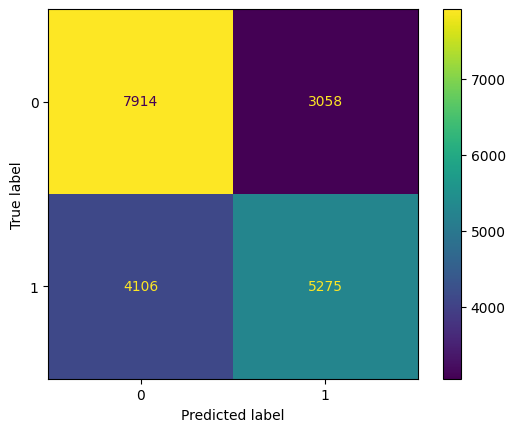

In [88]:
from sklearn.metrics import ConfusionMatrixDisplay

# Plot Confusion Matrix -- 0- Not readmitted, 1-Readmitted
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot()

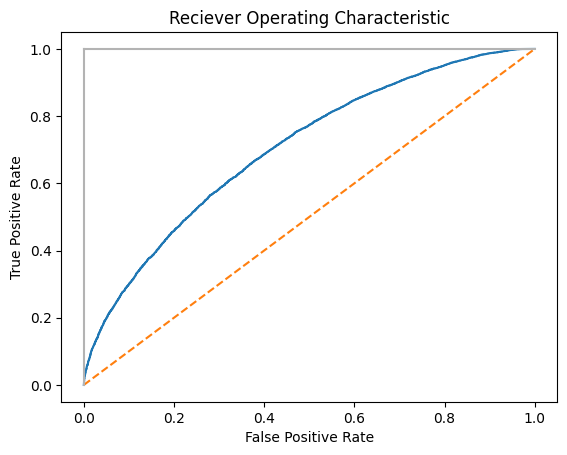

In [80]:
from sklearn.metrics import roc_curve

# create true and positive rates
false_positive_rate, true_positive_rate, threshold = roc_curve(y_test, y_proba_xgb)

# plot ROC curve
plt.title("Reciever Operating Characteristic")
plt.plot(false_positive_rate, true_positive_rate)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1,0], c=".7"), plt.plot([1, 1], c=".7")
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show()

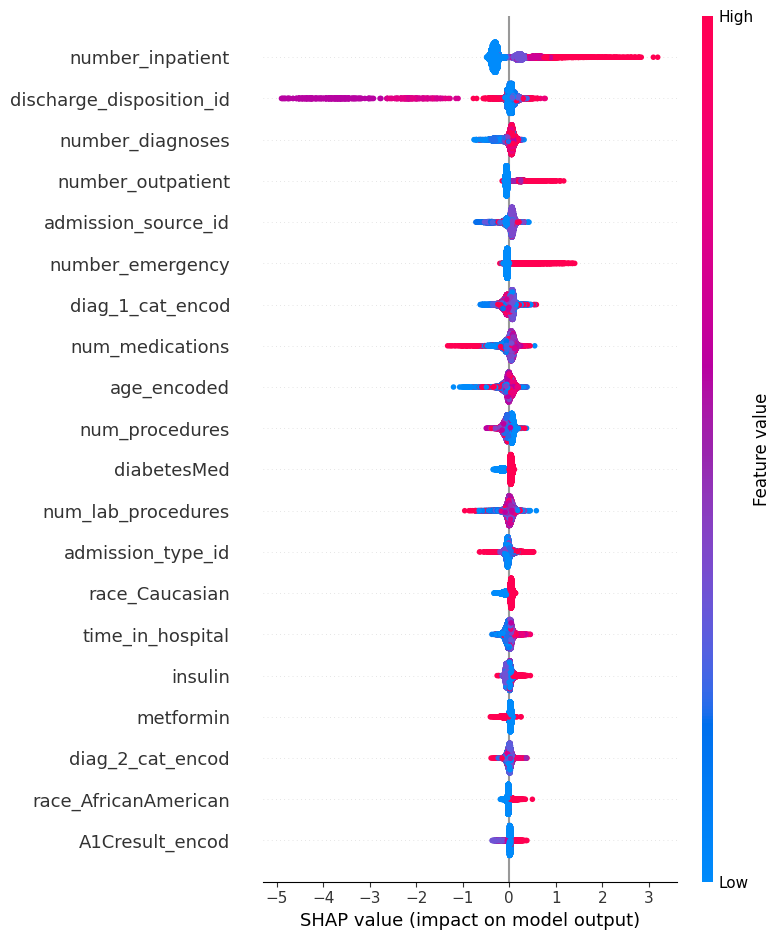

In [78]:
# explain feature contributions using SHAP.
import shap

# X_test to a dataframe
X_test_df = pd.DataFrame(X_test, columns=features.columns)

# Now use SHAP with this DataFrame
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_df)

shap.summary_plot(shap_values, X_test_df)

In [84]:
import tensorflow as tf

# Define the model - deep neural net
number_input_features = len(X_train_res[0])
hidden_nodes_layer1 = 14
hidden_nodes_layer2 = 10

model = tf.keras.models.Sequential()

# First hidden layer
first_layer = tf.keras.layers.Dense(units=hidden_nodes_layer1, input_dim=number_input_features, activation="relu")
model.add(first_layer)


# Second hidden layer
second_layer = tf.keras.layers.Dense(units=hidden_nodes_layer2, activation="relu")
model.add(second_layer)


# Output layer
output_layer = tf.keras.layers.Dense(units=1, activation="sigmoid")
model.add(output_layer)

# Compile the Sequential model together and customize metrics
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

# Train the model
dl_model = model.fit(X_train_res, y_train_res, epochs=100)

Epoch 1/100


C:\Users\abram\anaconda3\envs\mlenv\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2744/2744 ━━━━━━━━━━━━━━━━━━━━ 3s 685us/step - accuracy: 0.5623 - loss: 0.6776
Epoch 2/100
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 2s 678us/step - accuracy: 0.6150 - loss: 0.6504
Epoch 3/100
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 2s 673us/step - accuracy: 0.6160 - loss: 0.6479
Epoch 4/100
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 2s 714us/step - accuracy: 0.6204 - loss: 0.6459
Epoch 5/100
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 2s 743us/step - accuracy: 0.6200 - loss: 0.6451
Epoch 6/100
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 2s 689us/step - accuracy: 0.6258 - loss: 0.6433
Epoch 7/100
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 2s 686us/step - accuracy: 0.6243 - loss: 0.6438
Epoch 8/100
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 2s 714us/step - accuracy: 0.6250 - loss: 0.6429
Epoch 9/100
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 2s 678us/step - accuracy: 0.6245 - loss: 0.6408
Epoch 10/100
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 2s 686us/step - accuracy: 0.6274 - loss: 0.6404
Epoch 11/100
2744/2744 ━━━━━━━━━━━━━━━━━━━━ 2s 708us/step - accuracy: 0.6302 - loss: 0.6382
Epoch 12/

In [87]:
# Evaluate the model using the test data
model_loss, model_accuracy = model.evaluate(X_test,y_test,verbose=2)
print(f"Loss: {model_loss}, Accuracy: {model_accuracy}")

637/637 - 0s - 773us/step - accuracy: 0.6304 - loss: 0.6336
Loss: 0.6335572004318237, Accuracy: 0.6303738951683044
